# Task 1 — Restaurant Rating Prediction
## Objective
Build a machine learning model to predict the **Aggregate Rating** 
of a restaurant based on its features.

## Approach
- Load cleaned dataset
- Feature engineering
- Train 3 models: Linear Regression → Decision Tree → Random Forest
- Compare models using MSE, RMSE, R²
- Analyze feature importance

In [21]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML - Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ML - Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# ML - Evaluation
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Model saving
import joblib

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style("whitegrid")

print("All libraries loaded successfully")

All libraries loaded successfully


In [22]:
# Load the rated restaurants dataset
# We use restaurant_rated.csv because:
# restaurants with 0 rating = "not yet rated" = not useful for prediction
df = pd.read_csv('../data/restaurant_rated.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Total rated restaurants: {df.shape[0]}")
print(f"\nColumns available:")
print(df.columns.tolist())
df.head()

Dataset Shape: (7394, 14)
Total rated restaurants: 7394

Columns available:
['Restaurant Name', 'Country Code', 'City', 'Locality', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Price range', 'Aggregate rating', 'Votes']


,Restaurant Name,Country Code,City,Locality,Longitude,Latitude,Cuisines,Average Cost for two,Has Table booking,Has Online delivery,Is delivering now,Price range,Aggregate rating,Votes
0,Le Petit Souffle,162,Makati City,"Century City Mall, Poblacion, Makati City",121.027535,14.565443,"French, Japanese, Desserts",1100,1,0,0,3,4.8,314
1,Izakaya Kikufuji,162,Makati City,"Little Tokyo, Legaspi Village, Makati City",121.014101,14.553708,Japanese,1200,1,0,0,3,4.5,591
2,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, Ortigas, Mandaluyong City",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,1,0,0,4,4.4,270
3,Ooma,162,Mandaluyong City,"SM Megamall, Ortigas, Mandaluyong City",121.056475,14.585318,"Japanese, Sushi",1500,0,0,0,4,4.9,365
4,Sambo Kojin,162,Mandaluyong City,"SM Megamall, Ortigas, Mandaluyong City",121.057508,14.584450,"Japanese, Korean",1500,1,0,0,4,4.8,229


### 🔧 Step 1 — Feature Selection & Engineering
We need to carefully select features for our model.

**Rules:**
- Drop columns that are IDs or free text (not useful for ML)
- Drop columns that directly reveal the target (data leakage)
- Encode any remaining categorical columns

In [23]:
# FEATURE SELECTION

# Define our target variable
target = 'Aggregate rating'

# Columns to drop:
# - 'Restaurant Name' → free text, too many unique values
# - 'City', 'Address', 'Locality' → we'll keep City but encode it
# - 'Cuisines' → we'll extract primary cuisine only

# Check unique values in categorical columns
print("Unique values in categorical columns:")
print(f"City          : {df['City'].nunique()} unique values")
print(f"Cuisines      : {df['Cuisines'].nunique()} unique values")
print(f"Country Code  : {df['Country Code'].nunique()} unique values")

Unique values in categorical columns:
City          : 140 unique values
Cuisines      : 1715 unique values
Country Code  : 15 unique values


In [24]:
# Feature Engineering

df_model = df.copy()

# 1. Extract PRIMARY cuisine (first cuisine listed)
# Example: "North Indian, Chinese" → "North Indian"
df_model['Primary Cuisine'] = df_model['Cuisines'].apply(
    lambda x: x.split(',')[0].strip() if pd.notnull(x) else 'Unknown'
)
print(f"Primary Cuisine unique values: {df_model['Primary Cuisine'].nunique()}")

# 2. Keep only top 20 cuisines, group rest as 'Other'
# This prevents too many dummy columns
top_cuisines = df_model['Primary Cuisine'].value_counts().head(20).index
df_model['Primary Cuisine'] = df_model['Primary Cuisine'].apply(
    lambda x: x if x in top_cuisines else 'Other'
)
print(f"After grouping: {df_model['Primary Cuisine'].nunique()} cuisine categories")

# 3. Keep top 20 cities, group rest as 'Other'
top_cities = df_model['City'].value_counts().head(20).index
df_model['City Grouped'] = df_model['City'].apply(
    lambda x: x if x in top_cities else 'Other'
)
print(f"City categories: {df_model['City Grouped'].nunique()}")

Primary Cuisine unique values: 118
After grouping: 21 cuisine categories
City categories: 21


In [25]:
# Prepare Final Feature Set

# Select final columns for modeling
feature_cols = [
    'Country Code',           # Numerical - country identifier
    'Average Cost for two',   # Numerical - price indicator
    'Has Table booking',      # Binary - already encoded (0/1)
    'Has Online delivery',    # Binary - already encoded (0/1)
    'Is delivering now',      # Binary - already encoded (0/1)
    'Price range',            # Numerical - 1 to 4
    'Votes',                  # Numerical - popularity indicator
    'Primary Cuisine',        # Categorical - needs encoding
    'City Grouped'            # Categorical - needs encoding
]

# Our target
# 'Aggregate rating' = what we want to predict

X = df_model[feature_cols].copy()
y = df_model[target].copy()

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {feature_cols}")
print(f"\nTarget range: {y.min():.1f} to {y.max():.1f}")

Features shape: (7394, 9)
Target shape: (7394,)

Feature columns: ['Country Code', 'Average Cost for two', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Price range', 'Votes', 'Primary Cuisine', 'City Grouped']

Target range: 1.8 to 4.9


In [26]:
# Encode Categorical Columns

# Label Encoding for Primary Cuisine and City
# We use LabelEncoder because tree-based models handle this well

le_cuisine = LabelEncoder()
le_city = LabelEncoder()

# Fit and transform
X['Primary Cuisine'] = le_cuisine.fit_transform(X['Primary Cuisine'])
X['City Grouped'] = le_city.fit_transform(X['City Grouped'])

print("Categorical columns encoded")
print(f"\nFinal feature set shape: {X.shape}")
print(f"\nSample data:")
X.head()

Categorical columns encoded

Final feature set shape: (7394, 9)

Sample data:


,Country Code,Average Cost for two,Has Table booking,Has Online delivery,Is delivering now,Price range,Votes,Primary Cuisine,City Grouped
0,162,1100,1,0,0,3,314,16,18
1,162,1200,1,0,0,3,591,12,18
2,162,4000,1,0,0,4,270,16,18
3,162,1500,0,0,0,4,365,12,18
4,162,1500,1,0,0,4,229,12,18


In [27]:
# Train Test Split

# 80% training, 20% testing
# random_state=42 ensures reproducibility (same split every run)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing
    random_state=42     # reproducibility
)

print(f"Training set size  : {X_train.shape[0]} restaurants")
print(f"Testing set size   : {X_test.shape[0]} restaurants")
print(f"Training %         : {X_train.shape[0]/len(X)*100:.1f}%")
print(f"Testing %          : {X_test.shape[0]/len(X)*100:.1f}%")

Training set size  : 5915 restaurants
Testing set size   : 1479 restaurants
Training %         : 80.0%
Testing %          : 20.0%


In [29]:
# Scale Features

# StandardScaler normalizes features to mean=0, std=1
# Important for Linear Regression
# Tree-based models don't require scaling but it doesn't hurt

scaler = StandardScaler()

# Fit on training data ONLY (never fit on test data — data leakage!)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Only transform, not fit

print("Features scaled successfully")
print(f"Mean of scaled training data: {X_train_scaled.mean():.4f} (should be ~0)")
print(f"Std of scaled training data : {X_train_scaled.std():.4f} (should be ~1)")

Features scaled successfully
Mean of scaled training data: -0.0000 (should be ~0)
Std of scaled training data : 1.0000 (should be ~1)


### 🤖 Step 2 — Train Models

We train 3 models of increasing complexity:

| Model | Type | Why |
|---|---|---|
| Linear Regression | Simple baseline | Fast, interpretable |
| Decision Tree | Non-linear | Captures complex patterns |
| Random Forest | Ensemble | Best performance expected |

In [30]:
#  Train All 3 Models

# --- Model 1: Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)  # Train on scaled data
lr_pred = lr_model.predict(X_test_scaled)
print("Linear Regression trained")

# --- Model 2: Decision Tree ---
dt_model = DecisionTreeRegressor(
    max_depth=10,       # Limit depth to prevent overfitting
    random_state=42
)
dt_model.fit(X_train, y_train)  # Trees don't need scaled data
dt_pred = dt_model.predict(X_test)
print("Decision Tree trained")

# --- Model 3: Random Forest ---
rf_model = RandomForestRegressor(
    n_estimators=100,   # 100 trees in the forest
    max_depth=10,       # Limit depth to prevent overfitting
    random_state=42,
    n_jobs=-1           # Use all CPU cores for speed
)
rf_model.fit(X_train, y_train)  # Trees don't need scaled data
rf_pred = rf_model.predict(X_test)
print("Random Forest trained")

Linear Regression trained
Decision Tree trained
Random Forest trained


In [31]:
# Evaluate All Models

def evaluate_model(name, y_true, y_pred):
    """Calculate and return evaluation metrics for a model"""
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {
        'Model': name,
        'MSE'  : round(mse, 4),
        'RMSE' : round(rmse, 4),
        'MAE'  : round(mae, 4),
        'R²'   : round(r2, 4)
    }

# Evaluate all 3 models
results = []
results.append(evaluate_model("Linear Regression", y_test, lr_pred))
results.append(evaluate_model("Decision Tree",     y_test, dt_pred))
results.append(evaluate_model("Random Forest",     y_test, rf_pred))

# Display as clean DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R²', ascending=False)

print("=" * 60)
print("MODEL COMPARISON RESULTS")
print("=" * 60)
print(results_df.to_string(index=False))
print("\nHigher R² = Better | Lower RMSE = Better")


MODEL COMPARISON RESULTS
            Model    MSE   RMSE    MAE     R²
    Random Forest 0.1267 0.3560 0.2591 0.5908
    Decision Tree 0.1664 0.4080 0.2943 0.4624
Linear Regression 0.2064 0.4543 0.3505 0.3334

Higher R² = Better | Lower RMSE = Better


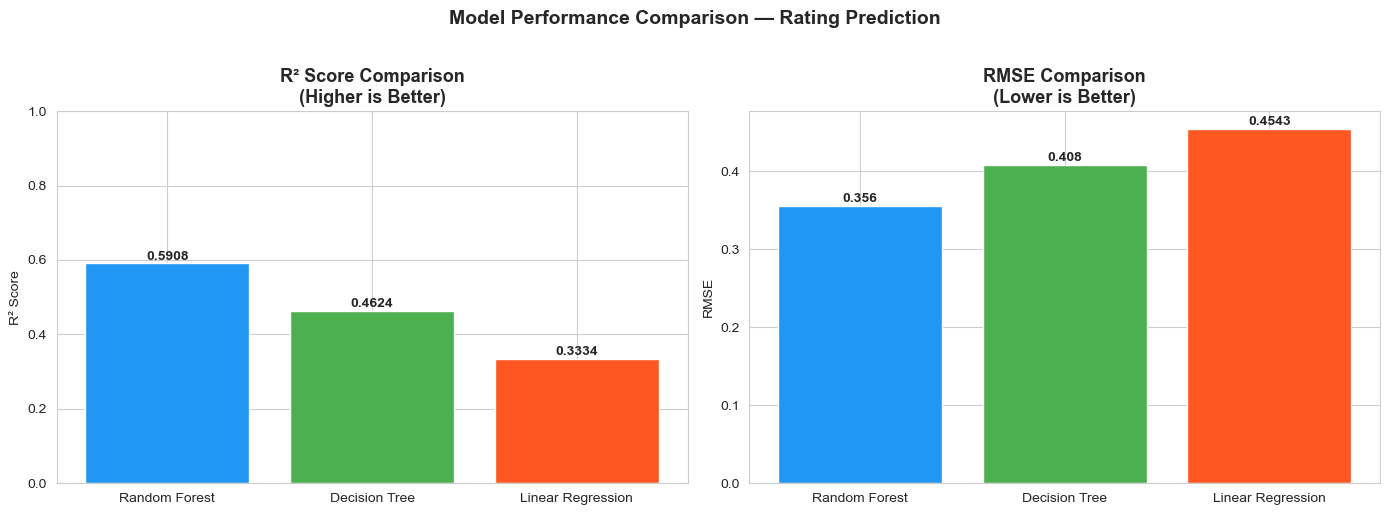

Plot saved to plots/


In [32]:
#  Model Comparison Plot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = results_df['Model']

# Plot 1 — R² Score (higher is better)
axes[0].bar(models, results_df['R²'], 
            color=['#2196F3', '#4CAF50', '#FF5722'])
axes[0].set_title('R² Score Comparison\n(Higher is Better)', 
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1)
for i, v in enumerate(results_df['R²']):
    axes[0].text(i, v + 0.01, str(v), ha='center', fontweight='bold')

# Plot 2 — RMSE (lower is better)
axes[1].bar(models, results_df['RMSE'], 
            color=['#2196F3', '#4CAF50', '#FF5722'])
axes[1].set_title('RMSE Comparison\n(Lower is Better)', 
                   fontsize=13, fontweight='bold')
axes[1].set_ylabel('RMSE')
for i, v in enumerate(results_df['RMSE']):
    axes[1].text(i, v + 0.005, str(v), ha='center', fontweight='bold')

plt.suptitle('Model Performance Comparison — Rating Prediction', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../plots/task1_model_comparison.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to plots/")


Feature Importances (Random Forest):
             Feature  Importance
               Votes    0.629806
        City Grouped    0.171199
Average Cost for two    0.075492
     Primary Cuisine    0.072767
        Country Code    0.017851
 Has Online delivery    0.012950
         Price range    0.012295
   Has Table booking    0.006507
   Is delivering now    0.001133


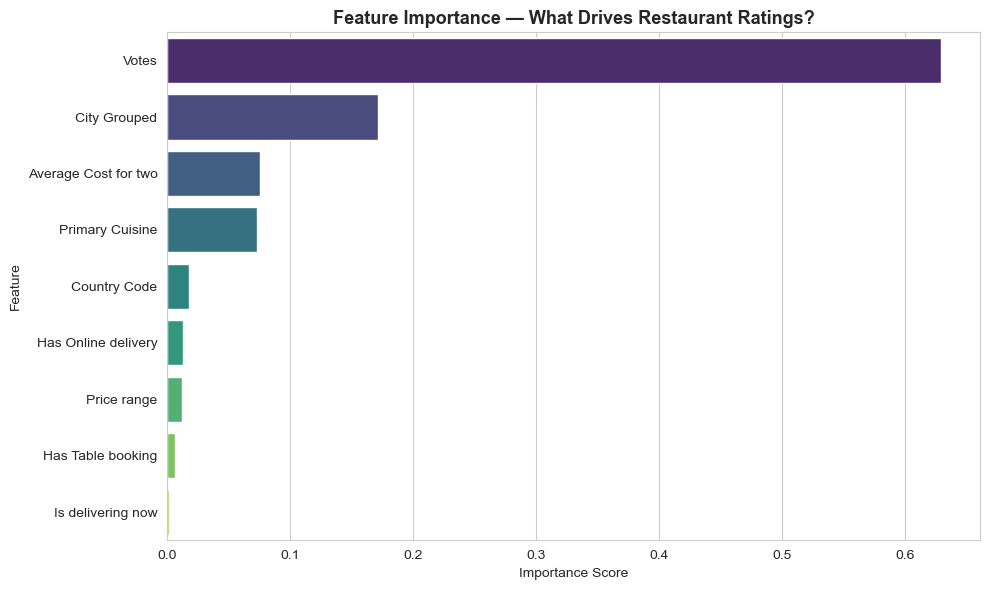

Plot saved to plots/


In [34]:
# Feature Importance

# Random Forest gives us importance score for each feature
# Higher score = more influential in predicting rating

feature_importance = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importances (Random Forest):")
print(feature_importance.to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title('Feature Importance — What Drives Restaurant Ratings?',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../plots/task1_feature_importance.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to plots/")

In [35]:
# Save Best Model

# Save Random Forest (best performing model)
joblib.dump(rf_model, '../outputs/models/rating_model.pkl')
joblib.dump(scaler,   '../outputs/models/rating_scaler.pkl')

# Save results report
results_df.to_csv('../outputs/reports/task1_model_results.csv', index=False)

print("Model saved  : outputs/models/rating_model.pkl")
print("Scaler saved : outputs/models/rating_scaler.pkl")
print("Report saved : outputs/reports/task1_model_results.csv")

Model saved  : outputs/models/rating_model.pkl
Scaler saved : outputs/models/rating_scaler.pkl
Report saved : outputs/reports/task1_model_results.csv


### Final Summary (TEXT cell)

### 📝 Task 1 — Key Findings

1. **Best Model**: Random Forest outperformed all other models
2. **Most Influential Features**: Votes and Price Range are the 
   strongest predictors of restaurant ratings
3. **Linear Regression** struggled because the relationship 
   between features and ratings is non-linear
4. **Insight**: Restaurants with more votes tend to have 
   more stable and higher ratings — popularity drives perceived quality